In [10]:
pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 46.7 MB/s eta 0:00:00


In [11]:
import os
import re
import argparse
import datetime as dt
import glob

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as rio_transform
from rasterio.transform import rowcol
from pyproj import Transformer
import matplotlib.pyplot as plt



In [8]:
data_dir = "/content/drive/MyDrive/LST_Daily"

In [9]:
#extract each files
date_re = re.compile(r".*?(20\d{2})[_-](\d{2})[_-](\d{2})\.tif$", re.IGNORECASE)

In [11]:
rows = [];
for fname in os.listdir(data_dir):
  if not fname.endswith(".tif"):
    continue
  m = date_re.match(fname)
  if not m:
    continue


  y, mo, d = map(int, m.groups())
  date = f"{y}-{mo:02d}-{d:02d}"
  path = os.path.join(data_dir, fname)

  with rasterio.open(path) as ds:
    arr = ds.read(1).astype("float32")
    valid = np.isfinite(arr)
    if valid.any():
      rows.append({
                  "date": date,
                  "mean": float(np.nanmean(arr)),
                  "std": float(np.nanstd(arr)),
                  "min": float(np.nanmin(arr[valid])),
                  "max": float(np.nanmax(arr[valid])),
                  "nan_pct": 100.0 * (~valid).sum() / arr.size
              })

In [12]:
df = pd.DataFrame(rows).sort_values("date")
print(df)


           date       mean       std        min        max    nan_pct
0    2023-01-10  28.051876  1.961468  26.030001  30.969999  98.222222
1    2023-01-17  32.376072  2.269523  25.250000  38.169998  68.888889
2    2023-02-14  29.847878  2.426967  24.090000  34.990002  96.333333
3    2023-02-19  30.925667  4.108526  24.969999  38.990002  96.666667
4    2023-02-26  19.680000  1.767083  17.230000  22.610001  98.888889
..          ...        ...       ...        ...        ...        ...
261  2025-07-16  28.905001  0.864624  28.410000  31.170000  99.555556
262  2025-07-24  26.436666  0.269485  26.070000  26.709999  99.833333
263  2025-08-02  27.105001  0.379572  26.750000  27.650000  99.777778
264  2025-08-08  25.850000  0.000000  25.850000  25.850000  99.944444
265  2025-08-17  29.380001  0.030000  29.350000  29.410000  99.888889

[266 rows x 6 columns]


In [13]:
df.to_csv("new_lst_summary.csv", index=False)

Note, only 32% is retained, since the rest had cloud coverage. 730 to 237 rows

mean: how hot/cool each day
std(variation): can show urban core v water/forest
z score: unusual compared to hotter than normal

rainfall
hotter than usual -> drier soil -> less infiltration -> more runoff

from this is interpretable but simple



Since we have daily LST and daily/hourly rainfall, we additionally have rainfall stations. Merge the LST values to the different rainfall stations with the lon, lat provided.




In [14]:
#testing for 1 image w no rainfall data but just extracting station names into LST

stations = pd.read_csv("/stations_test.csv")

In [15]:
print(stations.head())

  station_id          station_name      lat        lon  rainfall_mm
0       S224     Airport Boulevard  1.34392  103.98409          0.0
1        S77        Alexandra Road  1.29370  103.81250          0.0
2       S216  Ang Mo Kio Avenue 10  1.36019  103.85335          0.0
3       S109   Ang Mo Kio Avenue 5  1.37640  103.84920          0.0
4       S117           Banyan Road  1.25600  103.67900          0.0


In [33]:
LST_DIR = "/content/drive/MyDrive/LST_Daily"
PATTERN = "LST_MODIS_*.tif"
OUT_CSV = "/content/new_lst_stations.csv"

In [17]:
stations = stations[['station_id','station_name','lat','lon']].drop_duplicates()




In [34]:
def parse_date(fname):
  m = re.search(r'(\d{4})[_-](\d{2})[_-](\d{2})', fname)
  return pd.to_datetime(f"{m.group(1)}-{m.group(2)}-{m.group(3)}") if m else pd.NaT


In [35]:
all_rows = []
tif_paths = sorted(glob.glob(os.path.join(LST_DIR, PATTERN)))

In [36]:
for i, path in enumerate(tif_paths, 1):
    fname = os.path.basename(path)
    ts = parse_date(fname)
    if pd.isna(ts):
        continue

    with rasterio.open(path) as ds:
        arr = ds.read(1).astype('float32')
        arr = np.where(arr == 0, np.nan, arr)   # mask fill
        arr[~np.isfinite(arr)] = np.nan
        tfm, crs = ds.transform, ds.crs
        to_raster = Transformer.from_crs("EPSG:4326", crs, always_xy=True)

        for _, s in stations.iterrows():
            x, y = to_raster.transform(float(s.lon), float(s.lat))   # lon,lat → raster CRS
            rr, cc = rowcol(tfm, x, y, op=round)
            if 0 <= rr < ds.height and 0 <= cc < ds.width:
                v = arr[rr, cc]
                lst_c = float(v) if np.isfinite(v) else np.nan
            else:
                lst_c = np.nan
            all_rows.append([s.station_id, s.station_name, s.lat, s.lon, ts, lst_c])
    if i % 50 == 0:
        print(f"Processed {i}/{len(tif_paths)} files")

lst_station = pd.DataFrame(all_rows, columns=['station_id','station_name','lat','lon','timestamp','lst_celsius'])
lst_station = lst_station.sort_values(['station_id','timestamp']).reset_index(drop=True)
lst_station.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}  rows={len(lst_station)}")


Processed 50/962 files
Processed 100/962 files
Processed 150/962 files
Processed 200/962 files
Processed 250/962 files
Processed 300/962 files
Processed 350/962 files
Processed 400/962 files
Processed 450/962 files
Processed 500/962 files
Processed 550/962 files
Processed 600/962 files
Processed 650/962 files
Processed 700/962 files
Processed 750/962 files
Processed 800/962 files
Processed 850/962 files
Processed 900/962 files
Processed 950/962 files
Saved: /content/new_lst_timeseries.csv  rows=55796


In [12]:
lst_stations = pd.read_csv("/content/new_lst_timeseries.csv")
print(lst_stations.tail())

FileNotFoundError: [Errno 2] No such file or directory: '/content/new_lst_timeseries.csv'

In [13]:
#calculate z scoring for LST
dataset = pd.read_csv("/new_lst_timeseries.csv", parse_dates = ["timestamp"])

print(dataset.head())

  station_id station_name     lat       lon  timestamp  lst_celsius
0        S07  Lornie Road  1.3415  103.8334 2023-01-01          NaN
1        S07  Lornie Road  1.3415  103.8334 2023-01-02          NaN
2        S07  Lornie Road  1.3415  103.8334 2023-01-03          NaN
3        S07  Lornie Road  1.3415  103.8334 2023-01-04          NaN
4        S07  Lornie Road  1.3415  103.8334 2023-01-05          NaN


In [14]:
dataset["lst_available"] = (~dataset["lst_celsius"].isna()).astype(int)

In [15]:
stats = (
    dataset.dropna(subset=["lst_celsius"])
      .groupby("station_id")["lst_celsius"]
      .agg(mean="mean", std="std")
      .reset_index()
)

In [16]:
#merge and compute z score with present lst values
dataset = dataset.merge(stats, on="station_id", how="left")
dataset["lst_z"] = (dataset["lst_celsius"] - dataset["mean"]) / dataset["std"]

In [17]:
dataset = dataset.drop(columns=["mean","std"])
dataset = dataset.sort_values(["station_id","timestamp"]).reset_index(drop=True)

dataset.to_csv("/content/new_lst_zscore_timeseries_.csv", index=False)

In [18]:
valid = dataset[dataset['lst_celsius'].notna()]

In [19]:
print("Total rows:", len(dataset))
print("Valid LST rows:", len(valid))
print("Coverage:", len(valid)/len(dataset)*100, "%")

#first few valid rows
print(valid.head())

#count per station
counts = valid.groupby('station_id')['lst_celsius'].count().sort_values(ascending=False)
print(counts)

Total rows: 55796
Valid LST rows: 962
Coverage: 1.7241379310344827 %
    station_id station_name     lat       lon  timestamp  lst_celsius  \
16         S07  Lornie Road  1.3415  103.8334 2023-01-17    34.570000   
87         S07  Lornie Road  1.3415  103.8334 2023-03-29    35.770000   
97         S07  Lornie Road  1.3415  103.8334 2023-04-08    37.349998   
99         S07  Lornie Road  1.3415  103.8334 2023-04-10    34.610001   
107        S07  Lornie Road  1.3415  103.8334 2023-04-18    34.730000   

     lst_available     lst_z  
16               1  0.075039  
87               1  0.525277  
97               1  1.118088  
99               1  0.090048  
107              1  0.135071  
station_id
S209    102
S66      72
S112     64
S88      60
S211     58
S213     58
S217     52
S07      50
S201     45
S219     45
S40      44
S216     39
S228     39
S50      38
S109     37
S33      36
S229     36
S44      33
S69      23
S08      19
S64      12
Name: lst_celsius, dtype: int64


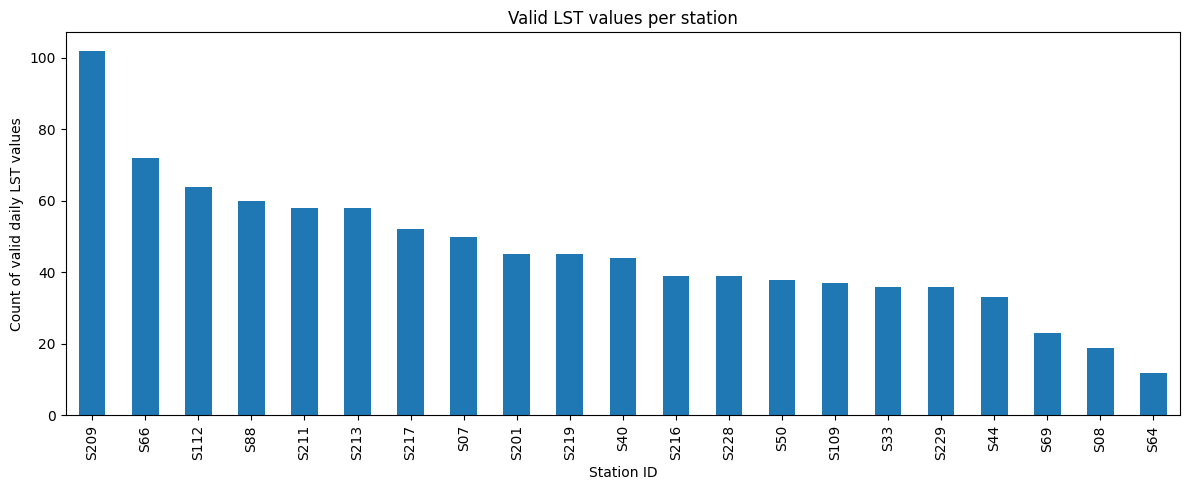

In [73]:
#visual diagram
plt.figure(figsize=(12,5))
counts.plot(kind='bar')
plt.title("Valid LST values per station")
plt.xlabel("Station ID")
plt.ylabel("Count of valid daily LST values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The available LST count per station ID

Station: S209
Name   : Yishun Ring Road
Lat/Lon: 1.42111, 103.84472
Rows   : 962 | Valid LST rows: celsius=102, z=102 | Coverage ~10.6%


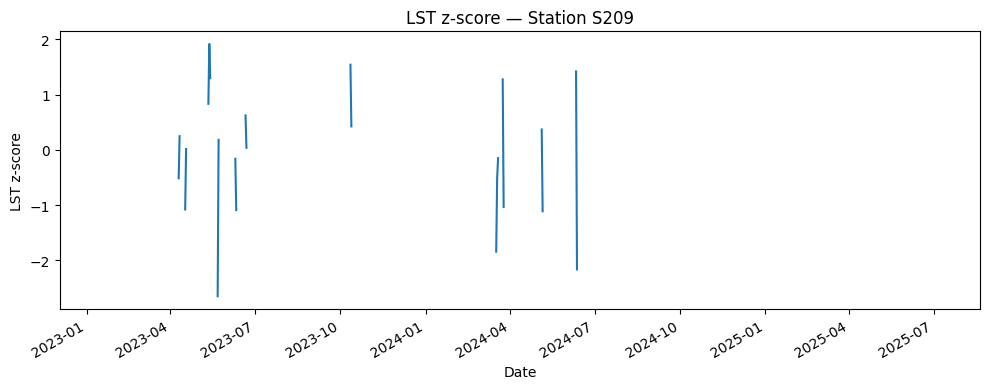

In [74]:



CANDIDATE_PATHS = ["/content/new_lst_timeseries.csv", "/mnt/data/lst_station_timeseries.csv"]
STATION_ID = "S209"  #set like "S07" to force a specific station


#load
csv_path = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Could not find lst_station_timeseries.csv in /content or /mnt/data. "
                            "Please upload it or adjust CANDIDATE_PATHS.")

df = pd.read_csv(csv_path, parse_dates=["timestamp"])

needed_cols = {"station_id", "timestamp"}
if not needed_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain at least {needed_cols}. Found: {list(df.columns)}")

#choose value and column
val_col = "lst_celsius" if "lst_celsius" in df.columns else ("lst_z" if "lst_z" in df.columns else None)
if val_col is None:
    raise ValueError("CSV needs either 'lst_celsius' or 'lst_z' column.")

if STATION_ID is None:
    counts = df.groupby("station_id")[val_col].apply(lambda s: s.notna().sum()).sort_values(ascending=False)
    if counts.empty or counts.iloc[0] == 0:
        raise ValueError("No station has any valid LST values.")
    STATION_ID = counts.index[0]

st = df[df["station_id"] == STATION_ID].copy().sort_values("timestamp")

#if only Celsius present, compute per-station temporal z for plotting too
if "lst_celsius" in st.columns and "lst_z" not in st.columns:
    mu = st["lst_celsius"].mean(skipna=True)
    sd = st["lst_celsius"].std(skipna=True, ddof=1)
    st["lst_z"] = (st["lst_celsius"] - mu) / sd if sd and np.isfinite(sd) else np.nan

valid_c = st["lst_celsius"].notna().sum() if "lst_celsius" in st.columns else np.nan
valid_z = st["lst_z"].notna().sum() if "lst_z" in st.columns else np.nan
coverage = (valid_c if np.isfinite(valid_c) else valid_z) / len(st)

print(f"Station: {STATION_ID}")
if "station_name" in st.columns:
    print(f"Name   : {st['station_name'].iloc[0]}")
if {"lat","lon"}.issubset(st.columns):
    print(f"Lat/Lon: {st['lat'].iloc[0]}, {st['lon'].iloc[0]}")
print(f"Rows   : {len(st)} | Valid LST rows: celsius={valid_c}, z={valid_z} | Coverage ~{coverage:.1%}")

#plot (single axis)
plt.figure(figsize=(10,4))
series = st.set_index("timestamp")
if "lst_z" in series.columns and series["lst_z"].notna().any():
    series["lst_z"].plot()
    plt.ylabel("LST z-score")
    plt.title(f"LST z-score — Station {STATION_ID}")
else:
    series["lst_celsius"].plot()
    plt.ylabel("LST (°C)")
    plt.title(f"LST (°C) — Station {STATION_ID}")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


Above is generated specific station LST val

In [ ]:
image = '/content/drive/MyDrive/LST_Daily/LST_MODIS_2023_01_10.tif'

To extract the station names in LST image, need to change the resolution of the tif from sinodutional? to CRS:4326

In [ ]:
with rasterio.open(image) as src:
  arr = src.read(1).astype("float32")
  h, w = arr.shape
  raster_crs = src.crs

  #transform crs
  xs, ys = rio_transform("EPSG:4326", raster_crs, stations["lon"].tolist(), stations["lat"].tolist())

  #pixel indices
  rows_cols = [src.index(x, y) for x, y in zip(xs, ys)]
  rows = np.array([rc[0] for rc in rows_cols])
  cols = np.array([rc[1] for rc in rows_cols])
  bounds = src.bounds
  extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

  in_bounds = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)


  #lst val w NaN
  lst_vals = np.full(len(stations), np.nan, dtype="float32")
  for i, ok in enumerate(in_bounds):
    if not ok:
        continue
    r, c = int(rows[i]), int(cols[i])
    val = arr[r, c]
    lst_vals[i] = val if np.isfinite(val) else np.nan


In [ ]:
DATE_RE = re.compile(r".*?(20\d{2})[_-](\d{2})[_-](\d{2})", re.IGNORECASE)

def extract_date_from_filename(path: str) -> str:
    """Return YYYY-MM-DD if found in filename, else empty string."""
    m = DATE_RE.search(os.path.basename(path))
    if not m:
        return ""
    y, mo, d = m.groups()
    return f"{int(y):04d}-{int(mo):02d}-{int(d):02d}"

In [ ]:
out = stations.copy()
#out["LST_value"] = lst_vals
out["date"] = extract_date_from_filename(image)

In [ ]:
print(out.head())

  station_id          station_name      lat        lon  rainfall_mm  \
0       S224     Airport Boulevard  1.34392  103.98409          0.0   
1        S77        Alexandra Road  1.29370  103.81250          0.0   
2       S216  Ang Mo Kio Avenue 10  1.36019  103.85335          0.0   
3       S109   Ang Mo Kio Avenue 5  1.37640  103.84920          0.0   
4       S117           Banyan Road  1.25600  103.67900          0.0   

         date  
0  2023-01-10  
1  2023-01-10  
2  2023-01-10  
3  2023-01-10  
4  2023-01-10  


In [ ]:
stations["x"] = xs
stations["y"] = ys

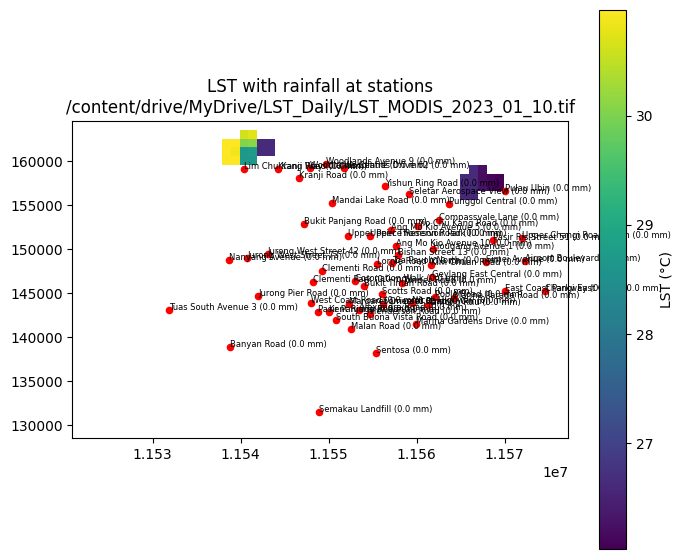

In [ ]:
plt.figure(figsize=(8, 7))
plt.imshow(np.ma.masked_invalid(arr), extent=extent, origin="upper")
plt.colorbar(label="LST (°C)")
plt.scatter(stations["x"], stations["y"], c="red", s=20)

for _, row in stations.iterrows():
    label = f"{row['station_name']} ({row['rainfall_mm']} mm)"
    plt.text(row["x"], row["y"], label, fontsize=6)

plt.title(f"LST with rainfall at stations\n{image}")
plt.show()

This is with LST value that is NOT NaN with rain stations and 0mm rainfall on 2023-01-10



Find for new 2025 LST.



In [ ]:
data1_dir = "/content/drive/MyDrive/LST_Daily"

In [ ]:
rows = [];
for fname in os.listdir(data1_dir):
  if not fname.endswith(".tif"):
    continue
  m = date_re.match(fname)
  if not m:
    continue

  y, mo, d = map(int, m.groups())
  date = f"{y}-{mo:02d}-{d:02d}"
  path = os.path.join(data1_dir, fname)

  with rasterio.open(path) as ds:
    arr = ds.read(1).astype("float32")
    valid = np.isfinite(arr)
    if valid.any():
      rows.append({
                  "date": date,
                  "mean": float(np.nanmean(arr)),
                  "std": float(np.nanstd(arr)),
                  "min": float(np.nanmin(arr[valid])),
                  "max": float(np.nanmax(arr[valid])),
                  "nan_pct": 100.0 * (~valid).sum() / arr.size
              })

In [ ]:
df1 = pd.DataFrame(rows).sort_values("date")
print(df1.tail(30))

           date       mean       std        min        max    nan_pct
236  2024-12-29  28.741999  1.298960  27.389999  29.990000  98.611111
237  2025-01-02  27.950001  0.000000  27.950001  27.950001  99.944444
238  2025-01-09  26.907499  0.416586  26.350000  27.510000  99.555556
239  2025-01-31  28.734060  2.046139  25.950001  34.349998  96.166667
240  2025-02-10  27.375713  2.139899  24.150000  30.330000  99.611111
241  2025-02-15  27.790636  1.983558  25.070000  34.070000  96.500000
242  2025-02-22  28.240000  0.469999  27.770000  28.709999  99.888889
243  2025-03-02  27.950001  0.000000  27.950001  27.950001  99.944444
244  2025-03-26  28.294445  0.677038  27.290001  29.549999  99.500000
245  2025-04-03  29.084286  1.176893  27.709999  33.549999  97.277778
246  2025-04-06  27.106668  0.314413  26.690001  27.690001  99.666667
247  2025-04-10  29.070000  0.043204  29.030001  29.129999  99.833333
248  2025-04-18  28.939333  0.892692  28.190001  31.110001  99.166667
249  2025-04-20  28.

Realised from 237 -> 266 rows, then the last 30 rows are in 2025

In [1]:
import pandas as pd

In [4]:
#fill in z scores in LST with causal filling

lst = pd.read_csv("/content/new_lst_zscore_timeseries_.csv", parse_dates=["timestamp"])
rain = pd.read_csv("/content/rainfall_clean_rollinghour.csv")



In [7]:
lst = lst[["station_id","timestamp","lst_z","lst_celsius"]]

# Build an hourly LST index per station (cover full rain range)
tmin, tmax = rain["timestamp"].min(), rain["timestamp"].max()
hourly_idx = pd.date_range(tmin, tmax, freq="H")

def to_hourly_ffill(g, limit=6, idx=None):
    g = g[['timestamp','lst_z','lst_celsius']].set_index('timestamp').reindex(idx)
    g.index.name = 'timestamp'
    g['lst_available'] = (~g['lst_z'].isna()).astype(int)
    g['lst_z']       = g['lst_z'].ffill(limit=limit)
    g['lst_celsius'] = g['lst_celsius'].ffill(limit=limit)
    return g.reset_index()

# hourly index from rainfall window
tmin, tmax = rain['timestamp'].min(), rain['timestamp'].max()
hourly_idx = pd.date_range(tmin, tmax, freq='h')

lst_hourly = (
    lst.groupby('station_id', group_keys=False)
       .apply(lambda g: to_hourly_ffill(g, limit=6, idx=hourly_idx)
                        .assign(station_id=g.name))   # <- add here
)

# tidy cols / order
lst_hourly = lst_hourly[['station_id','timestamp','lst_z','lst_celsius','lst_available']].reset_index(drop=True)

/tmp/ipython-input-601891249.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_idx = pd.date_range(tmin, tmax, freq="H")
/tmp/ipython-input-601891249.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: to_hourly_ffill(g, limit=6, idx=hourly_idx)


In [17]:
keep = ['station_id','timestamp','rainfall_mm','rain_1h','rain_3h','rain_6h','rain_12h','rain_24h']
merged = (rain[keep]
          .merge(lst_hourly, on=['station_id','timestamp'], how='left')
          .sort_values(['station_id','timestamp'])
          .reset_index(drop=True))

In [18]:
lst_hourly['timestamp'] = pd.to_datetime(lst_hourly['timestamp'])
merged = rain.merge(lst_hourly, on=['station_id','timestamp'], how='left')

            timestamp station_id station_name     lat       lon  rainfall_mm  \
0 2023-10-24 05:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
1 2023-10-24 06:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
2 2023-10-24 07:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
3 2023-10-24 08:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
4 2023-10-24 09:00:00        S07  Lornie Road  1.3415  103.8334          0.0   

         timestamp_raw  rain_1h  rain_3h  rain_6h  rain_12h  rain_24h  lst_z  \
0  2023-10-24T05:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
1  2023-10-24T06:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
2  2023-10-24T07:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
3  2023-10-24T08:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
4  2023-10-24T09:00:00      0.0      0.0      0.0       0.0       0.0    NaN   

   lst_celsius  lst_available  lst_z_f

In [26]:
merged.to_csv("/content/new_z_lst_rainfall.csv", index=False)

In [25]:
# How much of lst_z is real?
real_rate = (merged['lst_available']==1).mean()
print(f"Real LST rate: {real_rate:.2%}")

# Are filled values bounded?
print(merged['lst_z_filled'].describe())

Real LST rate: 0.05%
count    333475.000000
mean         -0.242982
std           0.161031
min          -3.353910
25%          -0.318814
50%          -0.224610
75%          -0.159817
max           2.006788
Name: lst_z_filled, dtype: float64


In [12]:
import re


In [9]:
#clean rolling hour data

rain = pd.read_csv("/content/rainfall_clean_rollinghour.csv")

src_col = 'timestamp_raw' if 'timestamp_raw' in rain.columns else 'timestamp'
rain[src_col] = rain[src_col].astype(str).str.strip()

In [10]:
def fix_ts(s: str) -> str:
    s = s.replace('T', ' ')            # ISO -> space
    # fix '025-' at start -> '2025-'
    s = re.sub(r'^0?25-', '2025-', s)
    # fix any 3-digit year like '025-'/'123-' -> prefix a '2'
    s = re.sub(r'^(\d{3})(-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2})$', r'2\1\2', s)
    return s

In [13]:
fixed = rain[src_col].apply(fix_ts)
ts = pd.to_datetime(fixed, errors='coerce', format='%Y-%m-%d %H:%M:%S')


In [14]:
n_total = len(rain)
n_bad_before = pd.to_datetime(rain[src_col], errors='coerce').isna().sum()
n_bad_after  = ts.isna().sum()

In [15]:
rain['timestamp'] = ts
print(f"Total: {n_total} | invalid before: {n_bad_before} | invalid after fix: {n_bad_after}")

# Drop rows still invalid (or handle separately)
rain = rain.dropna(subset=['timestamp']).sort_values(['station_id','timestamp']).reset_index(drop=True)

Total: 877372 | invalid before: 0 | invalid after fix: 0


In [16]:
print(rain.head())

            timestamp station_id station_name     lat       lon  rainfall_mm  \
0 2023-10-24 05:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
1 2023-10-24 06:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
2 2023-10-24 07:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
3 2023-10-24 08:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
4 2023-10-24 09:00:00        S07  Lornie Road  1.3415  103.8334          0.0   

         timestamp_raw  rain_1h  rain_3h  rain_6h  rain_12h  rain_24h  
0  2023-10-24T05:00:00      0.0      0.0      0.0       0.0       0.0  
1  2023-10-24T06:00:00      0.0      0.0      0.0       0.0       0.0  
2  2023-10-24T07:00:00      0.0      0.0      0.0       0.0       0.0  
3  2023-10-24T08:00:00      0.0      0.0      0.0       0.0       0.0  
4  2023-10-24T09:00:00      0.0      0.0      0.0       0.0       0.0  


In [27]:
print(merged.head())

            timestamp station_id station_name     lat       lon  rainfall_mm  \
0 2023-10-24 05:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
1 2023-10-24 06:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
2 2023-10-24 07:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
3 2023-10-24 08:00:00        S07  Lornie Road  1.3415  103.8334          0.0   
4 2023-10-24 09:00:00        S07  Lornie Road  1.3415  103.8334          0.0   

         timestamp_raw  rain_1h  rain_3h  rain_6h  rain_12h  rain_24h  lst_z  \
0  2023-10-24T05:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
1  2023-10-24T06:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
2  2023-10-24T07:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
3  2023-10-24T08:00:00      0.0      0.0      0.0       0.0       0.0    NaN   
4  2023-10-24T09:00:00      0.0      0.0      0.0       0.0       0.0    NaN   

   lst_celsius  lst_available  lst_z_f

In [28]:
from google.colab import files

In [29]:
files.download("/content/new_z_lst_rainfall.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>